<a href="https://colab.research.google.com/github/kirti12025/Data-science-/blob/main/A_B_Testing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Read the data
df = pd.read_csv('marketing_AB.csv')

In [3]:
#check such few observations
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130.0,Monday,20.0
1,1,1119715,ad,False,93.0,Tuesday,22.0
2,2,1144181,ad,False,21.0,Tuesday,18.0
3,3,1435133,ad,False,355.0,Tuesday,10.0
4,4,1015700,ad,False,276.0,Friday,14.0


In [4]:
#check if we have duplicate with respect to user id
df.duplicated(subset='user id').sum()

np.int64(0)

In [5]:
#Drop unwanted columns
df.drop(['Unnamed: 0','user id'],axis =1,inplace=True)

In [6]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [7]:
#check if the categorial variable have appropriate no of levels
df_cat = df[['test group','converted','most ads day','most ads hour']]
df_cat.nunique()

,0
test group,2
converted,2
most ads day,7
most ads hour,24


In [8]:
#check if the categorial variable have appropriate levels
for i in df_cat.columns:
  print(i.upper(),":",df_cat[i].unique())

TEST GROUP : ['ad' 'psa' nan]
CONVERTED : [False True nan]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday'
 nan]
MOST ADS HOUR : [20. 22. 18. 10. 14. 13. 19. 11. 12. 16. 21.  3. 23.  4.  8.  0.  2. 15.
  1.  6. 17.  7.  9.  5. nan]


In [9]:
#Univariate analysis

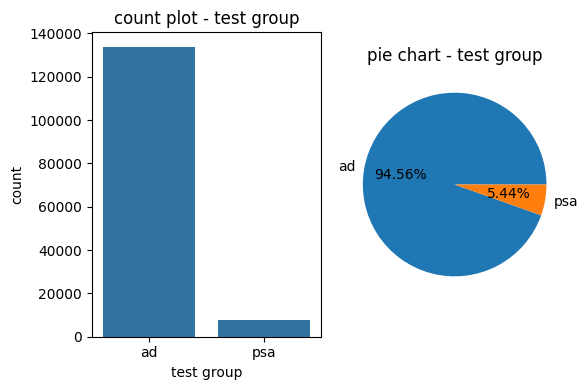

In [10]:
variable= 'test group'
plt.figure(figsize=(6,4))
#countplot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'count plot - {variable}')

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels=counts.index,autopct='%0.2f%%')
plt.title(f'pie chart - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

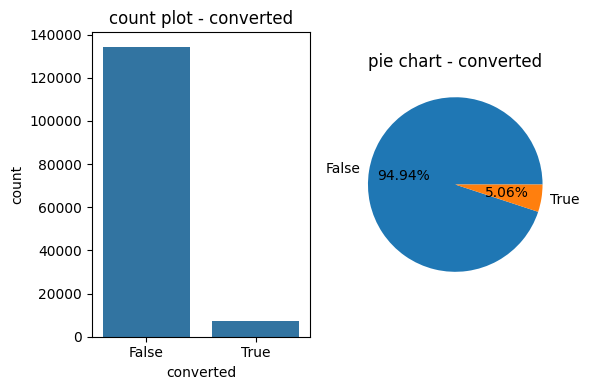

In [11]:
variable= 'converted'
plt.figure(figsize=(6,4))
#countplot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'count plot - {variable}')

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels=counts.index,autopct='%0.2f%%')
plt.title(f'pie chart - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

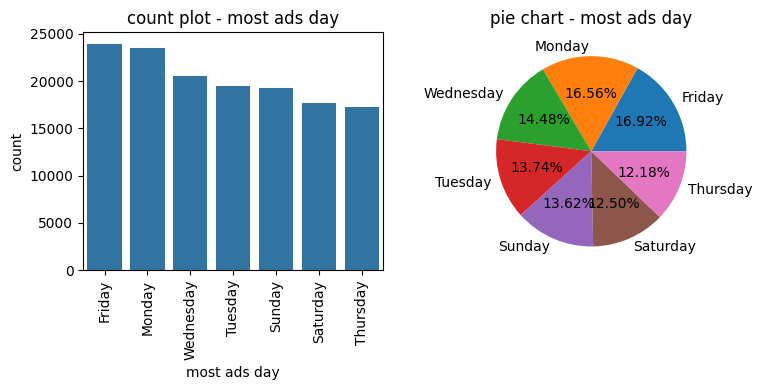

In [12]:
variable= 'most ads day'
plt.figure(figsize=(8,4))
#countplot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat,order=df_cat['most ads day'].value_counts().index)
plt.title(f'count plot - {variable}')
plt.xticks(rotation=90)

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels=counts.index,autopct='%0.2f%%')
plt.title(f'pie chart - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

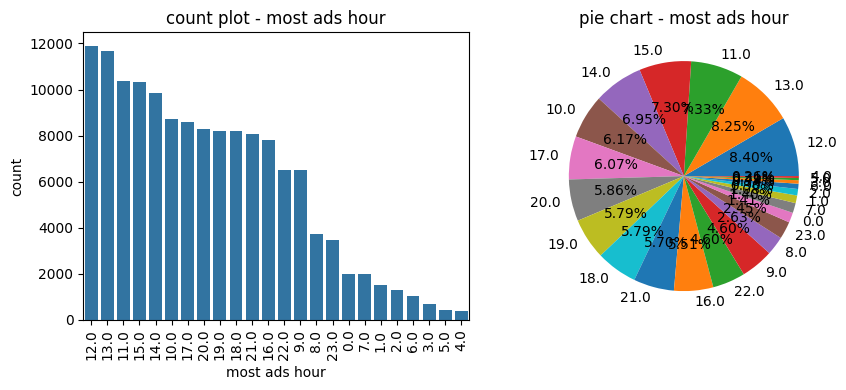

In [13]:
variable= 'most ads hour'
plt.figure(figsize=(9,4))
#countplot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat,order=df_cat['most ads hour'].value_counts().index)
plt.title(f'count plot - {variable}')
plt.xticks(rotation=90)

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels=counts.index,autopct='%0.2f%%')
plt.title(f'pie chart - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

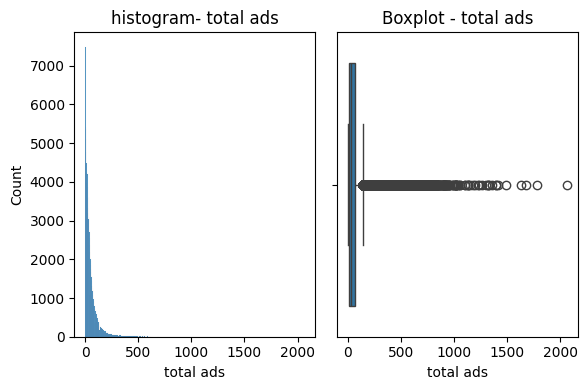

In [14]:
variable= 'total ads'
plt.figure(figsize=(6,4))
#Histogram
plt.subplot(1,2,1)
sns.histplot(x=variable, data=df)
plt.title(f'histogram- {variable}')

#pie chart
plt.subplot(1,2,2)
sns.boxplot(x=variable,data=df)
plt.title(f'Boxplot - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

In [15]:
#lets check the descriptive stats of this feature
df['total ads'].describe()

,total ads
count,141509.000000
mean,54.143037
std,74.125821
min,1.000000
25%,14.000000
50%,33.000000
75%,65.000000
max,2065.000000


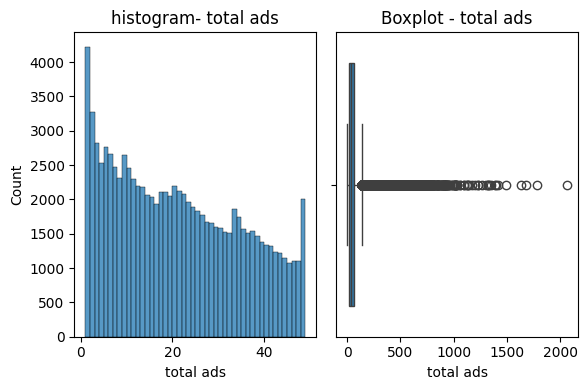

In [16]:
variable= 'total ads'
plt.figure(figsize=(6,4))
#Histogram
plt.subplot(1,2,1)
#filtering the data for a value close to 75th percentile only for better visualization
sns.histplot(x=variable, data=df[df['total ads']<50])
plt.title(f'histogram- {variable}')

#pie chart
plt.subplot(1,2,2)
sns.boxplot(x=variable,data=df)
plt.title(f'Boxplot - {variable}')

#Adjust layout
plt.tight_layout()

#Show the plots
plt.show()

In [17]:
#bivariate analysis

In [18]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [19]:
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize='index')
ct_conversion_test_group

converted,False,True
test group,,
ad,0.948239,0.051761
psa,0.969484,0.030516


converted      False     True 
test group                    
ad          0.948239  0.051761
psa         0.969484  0.030516


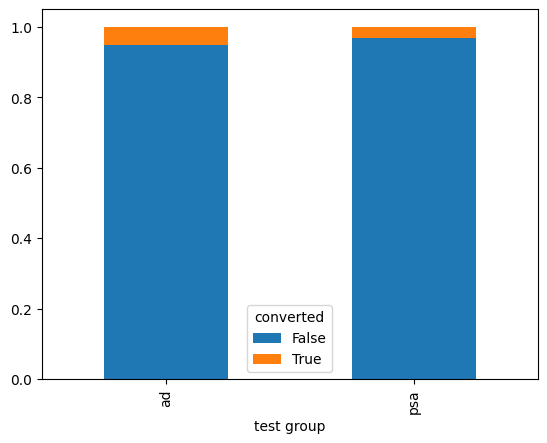

In [20]:
ct_conversion_day=pd.crosstab(df['test group'],df['converted'],normalize='index')
print(ct_conversion_day.sort_values(by=True,ascending=False))
ct_conversion_day.plot.bar(stacked=True);

<Axes: xlabel='test group'>

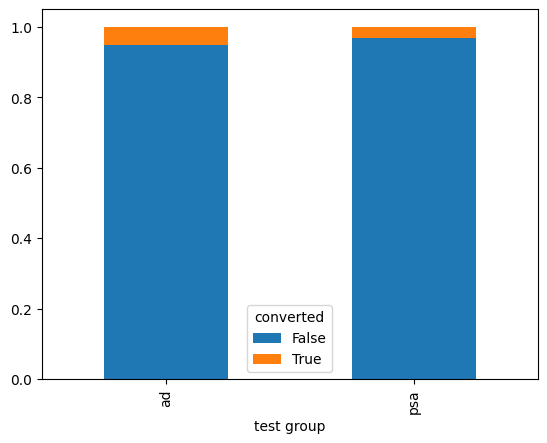

In [21]:
ct_conversion_test_group.plot.bar(stacked=True)

converted        False     True 
most ads day                    
Monday        0.939164  0.060836
Sunday        0.943381  0.056619
Tuesday       0.946968  0.053032
Saturday      0.950093  0.049907
Thursday      0.954208  0.045792
Friday        0.956282  0.043718
Wednesday     0.956363  0.043637


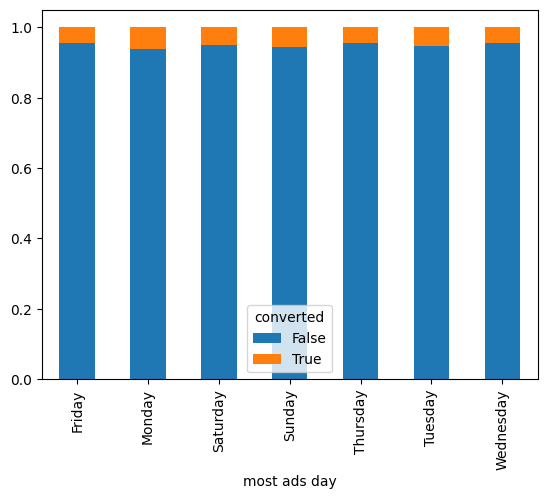

In [22]:
ct_conversion_day=pd.crosstab(df['most ads day'],df['converted'],normalize='index')
print(ct_conversion_day.sort_values(by=True,ascending=False))
ct_conversion_day.plot.bar(stacked=True);

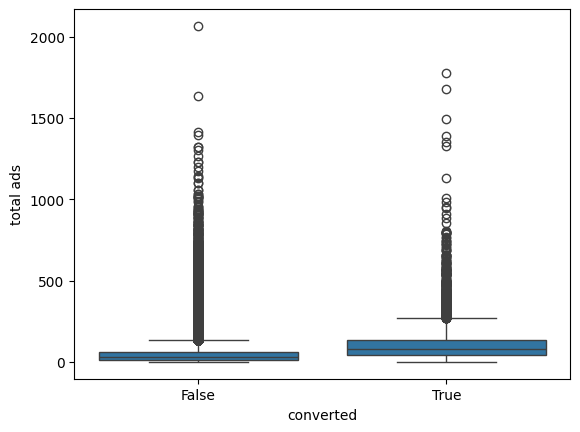

In [23]:
sns.boxplot(x='converted',y='total ads',data=df);

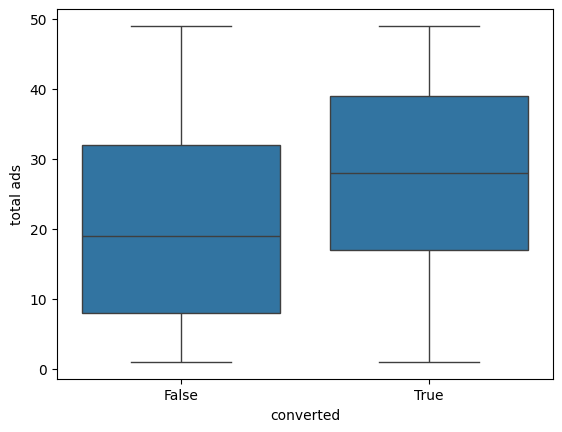

In [24]:
sns.boxplot(x='converted',y='total ads',data=df[df['total ads']<50]);

In [25]:
#statistical test

In [29]:
from scipy.stats import chi2_contingency
alpha=0.05
for variable in df_cat.columns:
  if variable !='converted':
    #create a contigency table
    contigency_table=pd.crosstab(df_cat[variable],df_cat['converted'])

    #perform chi square test
    chi2,p,_,_= chi2_contingency(contigency_table)
    #Display the results
    print(f"\nchi-square test for {variable} vs converted:")
    print(f"chi_square value: {chi2}")
    print(f"p-value:{p}")

    #check for signifance
    if p < alpha :
      print(f"the difference in conversion rates across {variable} is statistically significant")
    else:
      print(f"there is no significant difference in conversion rates across {variable}")


chi-square test for test group vs converted:
chi_square value: 67.9702461077036
p-value:1.6598134907629248e-16
the difference in conversion rates across test group is statistically significant

chi-square test for most ads day vs converted:
chi_square value: 120.79516935830237
p-value:1.1093025821167053e-23
the difference in conversion rates across most ads day is statistically significant

chi-square test for most ads hour vs converted:
chi_square value: 225.64056376654645
p-value:3.306075744736509e-35
the difference in conversion rates across most ads hour is statistically significant


In [30]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')

In [36]:
from scipy.stats import shapiro,levene,ttest_ind,mannwhitneyu

# Filter out NaN values from the 'converted' column for these tests
df_filtered = df.dropna(subset=['converted'])

#step1- check assumption
#normality assumption
shapiro_stats_true,shapiro_p_value_true=shapiro(df_filtered[df_filtered['converted'] == True]['total ads'])
shapiro_stats_false,shapiro_p_value_false=shapiro(df_filtered[df_filtered['converted'] == False]['total ads'])
print(f"shapiro_wilk test for normality (true group): p value={shapiro_p_value_true}")
print(f"shapiro_wilk test for normality (false group): p value={shapiro_p_value_false}")
#equality of variance assumption
levene_stats,levene_p_value = levene(df_filtered[df_filtered['converted'] == True]['total ads'],df_filtered[df_filtered['converted'] == False]['total ads'])
print(f"levene test for equality of variance : p_value={levene_p_value}")

#step2 perform a suitable test
alpha=0.05
if shapiro_p_value_true> alpha and shapiro_p_value_false> alpha and levene_p_value>alpha:
  #assumption met-use t-test for means
  t_stats,t_p_value = ttest_ind(df_filtered[df_filtered['converted'] == True]['total ads'],df_filtered[df_filtered['converted'] == False]['total ads'])
  print(f"independent two sample t-test: {t_p_value}")
else:
    #assumption not met-use mannwitney u tests for medians
    u_stats,u_p_value=mannwhitneyu(df_filtered[df_filtered['converted'] == True]['total ads'],df_filtered[df_filtered['converted'] == False]['total ads'])
    print(f"mann whitney u test : p_value={u_p_value}")

shapiro_wilk test for normality (true group): p value=5.066097980114773e-78
shapiro_wilk test for normality (false group): p value=3.114019887480332e-161
levene test for equality of variance : p_value=1.3399142392035056e-278
mann whitney u test : p_value=0.0
